In [8]:
import pandas as pd
df = pd.read_csv('C:/Users/Lenovo/OneDrive/Desktop/JARVIS/data/intent_dataset.csv')
# Original dataset

# Real-world feedback
real_df = pd.read_csv("../data/real_world_commands.csv")

df.head()

,text,intent,language
0,terminal kholo,AUTOMATION,hinglish
1,Delhi ka current weather kya hai,REAL_TIME,hinglish
2,open the camera,AUTOMATION,english
3,sound settings kholo,AUTOMATION,hinglish
4,What is IoT?,GENERAL,english


In [9]:
real_df.head()

,timestamp,text,predicted_intent,confidence,correct_intent
0,2026-09-09 15:37:31,what is machine learning,GENERAL,0.924178,GENERAL
1,2026-09-09 15:37:48,What is the temperature of Delhi today?,REAL_TIME,0.825152,REAL_TIME
2,2026-09-09 15:37:57,tell the current price of bitcoin,REAL_TIME,0.599434,REAL_TIME
3,2026-09-09 15:38:18,why do we use database,AUTOMATION,0.423259,GENERAL
4,2026-09-09 15:38:25,tell me latest cricket score,REAL_TIME,0.585810,REAL_TIME


In [10]:
reviewed = real_df[
    real_df["correct_intent"].notna() &
    (real_df["correct_intent"] != "")
].copy()

reviewed.head()

,timestamp,text,predicted_intent,confidence,correct_intent
0,2026-09-09 15:37:31,what is machine learning,GENERAL,0.924178,GENERAL
1,2026-09-09 15:37:48,What is the temperature of Delhi today?,REAL_TIME,0.825152,REAL_TIME
2,2026-09-09 15:37:57,tell the current price of bitcoin,REAL_TIME,0.599434,REAL_TIME
3,2026-09-09 15:38:18,why do we use database,AUTOMATION,0.423259,GENERAL
4,2026-09-09 15:38:25,tell me latest cricket score,REAL_TIME,0.585810,REAL_TIME


In [11]:
real_training = pd.DataFrame({
    "text": reviewed["text"],
    "intent": reviewed["correct_intent"]
})

real_training.head()

,text,intent
0,what is machine learning,GENERAL
1,What is the temperature of Delhi today?,REAL_TIME
2,tell the current price of bitcoin,REAL_TIME
3,why do we use database,GENERAL
4,tell me latest cricket score,REAL_TIME


In [12]:
df = pd.concat(
    [df, real_training],
    ignore_index=True
)

# Duplicate commands remove
df = df.drop_duplicates(
    subset="text",
    keep="first"
)

print("Total samples:", len(df))

Total samples: 957


In [13]:
df.shape

(957, 3)

In [14]:
df.head(10)

,text,intent,language
0,terminal kholo,AUTOMATION,hinglish
1,Delhi ka current weather kya hai,REAL_TIME,hinglish
2,open the camera,AUTOMATION,english
3,sound settings kholo,AUTOMATION,hinglish
4,What is IoT?,GENERAL,english
5,encryption kya hoti hai,GENERAL,hinglish
6,abhi check karo abhi weather kaisa hai abhi,REAL_TIME,hinglish
7,what is the AQI in Delhi right now,REAL_TIME,english
8,volume badhao,AUTOMATION,hinglish
9,what is the latest Microsoft news,REAL_TIME,english


In [15]:
df['intent'].value_counts

<bound method IndexOpsMixin.value_counts of 0      AUTOMATION
1       REAL_TIME
2      AUTOMATION
3      AUTOMATION
4         GENERAL
          ...    
959     REAL_TIME
960     REAL_TIME
961       GENERAL
962     REAL_TIME
963     REAL_TIME
Name: intent, Length: 957, dtype: object>

In [16]:
df['language'].value_counts

<bound method IndexOpsMixin.value_counts of 0      hinglish
1      hinglish
2       english
3      hinglish
4       english
         ...   
959         NaN
960         NaN
961         NaN
962         NaN
963         NaN
Name: language, Length: 957, dtype: object>

In [17]:
df.isnull().sum()

text        0
intent      0
language    6
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df['text'].duplicated().sum()

np.int64(0)

In [20]:
df[df['text'].duplicated(keep=False)].sort_values('text')

,text,intent,language


In [21]:
df = df.drop_duplicates(subset="text", keep="first")

In [25]:
df["text"].duplicated().sum()

np.int64(0)

In [26]:
pd.crosstab(df["intent"], df["language"])

language,english,hinglish
intent,,
AUTOMATION,154,149
GENERAL,194,182
REAL_TIME,136,136


In [27]:
df['text'].value_counts().sum()

np.int64(957)

In [28]:
pd.set_option("display.max_colwidth", None)

for intent in df["intent"].unique():
    print("\n================", intent, "================\n")
    print(df[df["intent"] == intent]["text"].sample(20, random_state=42).to_string(index=False))


================ AUTOMATION ================

                          discord kholo
                  cut the selected text
                          turn off wifi
                      recycle bin kholo
                   previous song chalao
Chrome kholo aur Google par search karo
                           open spotify
            set volume to fifty percent
                           vscode kholo
                 page ke bottom par jao
                          open pictures
                 move the selected file
                   undo the last action
                       cancel the timer
                      timer cancel karo
        turn the screen brightness down
             please chrome kholo please
                 recycle bin empty karo
                          wifi off karo
task manager kholo aur processes dikhao

================ REAL_TIME ================

                   what time is it now
                   breaking news batao
                     latest I

In [29]:
x = df['text']
y = df['intent']

In [30]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2)
)

x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(x_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [33]:
y_pred = model.predict(x_test_tfidf)

In [34]:
print(y_pred[:20])

['REAL_TIME' 'REAL_TIME' 'AUTOMATION' 'GENERAL' 'GENERAL' 'GENERAL'
 'GENERAL' 'REAL_TIME' 'GENERAL' 'GENERAL' 'REAL_TIME' 'AUTOMATION'
 'GENERAL' 'GENERAL' 'REAL_TIME' 'GENERAL' 'REAL_TIME' 'GENERAL'
 'AUTOMATION' 'AUTOMATION']


In [35]:
print(y_test.values[:20])

['REAL_TIME' 'REAL_TIME' 'AUTOMATION' 'GENERAL' 'GENERAL' 'GENERAL'
 'GENERAL' 'REAL_TIME' 'GENERAL' 'GENERAL' 'REAL_TIME' 'AUTOMATION'
 'GENERAL' 'GENERAL' 'REAL_TIME' 'GENERAL' 'REAL_TIME' 'GENERAL'
 'AUTOMATION' 'AUTOMATION']


In [36]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9947916666666666


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  AUTOMATION       0.98      1.00      0.99        61
     GENERAL       1.00      0.99      0.99        76
   REAL_TIME       1.00      1.00      1.00        55

    accuracy                           0.99       192
   macro avg       0.99      1.00      1.00       192
weighted avg       0.99      0.99      0.99       192



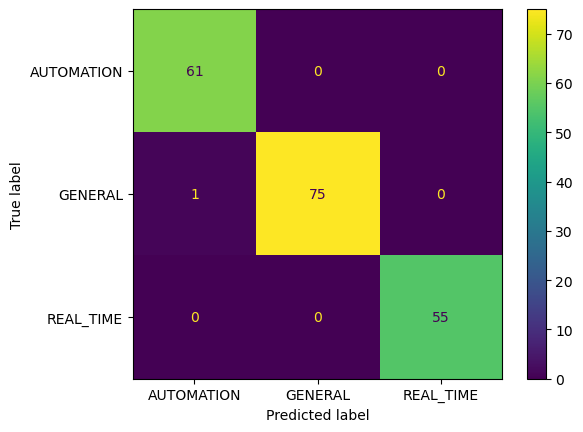

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.show()

In [39]:
test_sentences = [
    "bhai chrome chala do",
    "tell me something about neural networks",
    "aaj Delhi ka temperature kya hai",
    "laptop ki brightness kam kar do",
    "explain what an API does",
    "what is the latest cricket score",
    "youtube khol do",
    "why do we use databases",
    "bitcoin ka current price batao"
]

test_tfidf = vectorizer.transform(test_sentences)

predictions = model.predict(test_tfidf)

for text, prediction in zip(test_sentences, predictions):
    print(f"{text}  -->  {prediction}")

bhai chrome chala do  -->  AUTOMATION
tell me something about neural networks  -->  GENERAL
aaj Delhi ka temperature kya hai  -->  REAL_TIME
laptop ki brightness kam kar do  -->  AUTOMATION
explain what an API does  -->  GENERAL
what is the latest cricket score  -->  REAL_TIME
youtube khol do  -->  GENERAL
why do we use databases  -->  GENERAL
bitcoin ka current price batao  -->  REAL_TIME


In [40]:
import joblib

joblib.dump(model, "../models/intent_model.pkl")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

print("Model saved successfully!")

Model saved successfully!
